In [1]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import torch
import torchdiffeq
import torchsde
from torchdyn.core import NeuralODE
from torchvision import datasets, transforms
from torchvision.transforms import ToPILImage
from torchvision.utils import make_grid
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models.unet import UNetModel

savedir = "/mnt/afs/intern/fangwenhan/wzz-y/sss/conditional-flow-matching/examples/2D_tutorials/models/cond_mnist"
os.makedirs(savedir, exist_ok=True)

In [2]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 128
n_epochs = 12

trainset = datasets.MNIST(
    "../data",
    train=True,
    download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]),
)

train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, drop_last=True
)

In [3]:
#################################
#    Class Conditional CFM
#################################

sigma = 0.0
model = UNetModel(
    dim=(1, 28, 28), num_channels=32, num_res_blocks=1, num_classes=10, class_cond=True
).to(device)
optimizer = torch.optim.Adam(model.parameters())
FM = ConditionalFlowMatcher(sigma=sigma)
# Users can try target FM by changing the above line by
# FM = TargetConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [4]:
for epoch in range(n_epochs):
    for i, data in enumerate(train_loader):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        y = data[1].to(device)
        x0 = torch.randn_like(x1)
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
        vt = model(t, xt, y)
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        optimizer.step()
        print(f"epoch: {epoch}, steps: {i}, loss: {loss.item():.4}", end="\r")

In [5]:
# Save the model
save_path = os.path.join(savedir, "cfm_mnist_pretrain.pt")
torch.save(model, save_path)
print(f"Model saved to {save_path}")


Model saved to /mnt/afs/intern/fangwenhan/wzz-y/sss/conditional-flow-matching/examples/2D_tutorials/models/cond_mnist/cfm_mnist_pretrain.pt


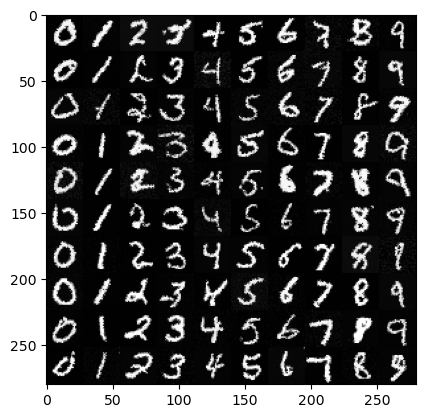

In [6]:
USE_TORCH_DIFFEQ = True
generated_class_list = torch.arange(10, device=device).repeat(10)
with torch.no_grad():
    if USE_TORCH_DIFFEQ:
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, generated_class_list),
            torch.randn(100, 1, 28, 28, device=device),
            torch.linspace(0, 1, 2, device=device),
            atol=1e-4,
            rtol=1e-4,
            method="dopri5",
        )
    else:
        traj = node.trajectory(
            torch.randn(100, 1, 28, 28, device=device),
            t_span=torch.linspace(0, 1, 2, device=device),
        )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)
plt.show()

In [6]:
# mnist_unlearn_digit_1.py
# 单次遗忘：在 class-conditional CFM 上“遗忘”类别 1
# 训练：仅当 y==1 时把目标替换为噪声，其余类别保持原训练目标
# 指标：与 2D 脚本一致的“区域占比”范式——用分类器判定生成样本是否为“1”
# 可视化：与预训练一致的 10×10 网格，对比图保存固定文件名

import os
import time
import numpy as np
import torch
import torch.nn as nn
import torchdiffeq
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

from torchcfm.conditional_flow_matching import ConditionalFlowMatcher
from torchcfm.models.unet import UNetModel

FORGET_CLASS = 1
USE_TORCH_DIFFEQ = True
SEED = 0

def set_seed(seed: int):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

# 轻量 MNIST 分类器（训练很快，精度足够评估占比）
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # 14x14
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*7*7, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def build_or_load_classifier(savedir, device, train_loader, test_loader, epochs=2, lr=1e-3):
    path = os.path.join(savedir, "mnist_cnn_classifier.pt")
    model = MNISTClassifier().to(device)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=device))
        model.eval()
        return model
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x), y)
            loss.backward(); opt.step()
        # 简单测试
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x).argmax(1)
                correct += (pred==y).sum().item()
                total += y.numel()
        acc = 100.0*correct/total
        print(f"[Classifier] epoch {ep+1}/{epochs} acc {acc:.2f}%")
        model.train()
    model.eval()
    torch.save(model.state_dict(), path)
    return model

def generate_grid(model, z0, generated_class_list, device):
    with torch.no_grad():
        if USE_TORCH_DIFFEQ:
            traj = torchdiffeq.odeint(
                lambda t, x: model.forward(t, x, generated_class_list),
                z0,
                torch.linspace(0, 1, 2, device=device),
                atol=1e-4, rtol=1e-4, method="dopri5",
            )
            x_final = traj[-1]
        else:
            x_final = z0
        grid = make_grid(x_final.view([-1,1,28,28]).clip(-1,1),
                         value_range=(-1,1), padding=0, nrow=10)
    return grid

@torch.no_grad()
def compute_forget_retain_rates(model, clf, device, n_samples=2048, n_classes=10):
    # 无条件生成：均匀取条件标签，积分到 t=1
    y_rand = torch.randint(0, n_classes, (n_samples,), device=device)
    z = torch.randn(n_samples, 1, 28, 28, device=device)
    traj = torchdiffeq.odeint(
        lambda t, x: model.forward(t, x, y_rand),
        z, torch.linspace(0, 1, 2, device=device),
        atol=1e-4, rtol=1e-4, method="dopri5",
    )
    xg = traj[-1].clamp(-1, 1)                         # [-1,1] 与训练归一化一致
    logits = clf(xg)                                    # 分类器判别“是否为1”
    preds = logits.argmax(1).cpu().numpy()
    forget_rate = (preds == FORGET_CLASS).mean() * 100.0  # 越小越好
    retain_rate = 100.0 - forget_rate
    return float(forget_rate), float(retain_rate)

def main():
    set_seed(SEED)
    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    savedir = "/mnt/afs/intern/fangwenhan/wzz-y/sss/conditional-flow-matching/examples/2D_tutorials/models/cond_mnist"
    os.makedirs(savedir, exist_ok=True)
    pretrain_path = os.path.join(savedir, "cfm_mnist_pretrain.pt")
    unlearn_path  = os.path.join(savedir, "cfm_mnist_unlearn_digit_1.pt")
    compare_img   = os.path.join(savedir, "mnist_pretrain_vs_unlearn_digit1.png")

    # 载入预训练生成器
    if not os.path.exists(pretrain_path):
        raise FileNotFoundError(f"未找到预训练权重: {pretrain_path}，请先运行 mnist.ipynb 预训练。")
    teacher = torch.load(pretrain_path, map_location=device).eval()

    # 数据 & 分类器（与生成器同归一化：ToTensor -> Normalize(0.5,0.5)）
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    trainset = datasets.MNIST("../data", train=True, download=True, transform=tf)
    testset  = datasets.MNIST("../data", train=False, download=True, transform=tf)
    train_loader_cls = DataLoader(trainset, batch_size=256, shuffle=True, drop_last=False)
    test_loader_cls  = DataLoader(testset,  batch_size=512, shuffle=False, drop_last=False)

    # 若已有分类器则直接载入，否则快速训练 2 个 epoch
    classifier = build_or_load_classifier(savedir, device, train_loader_cls, test_loader_cls, epochs=2)

    # 遗忘训练（仅修改 y==1 的目标为噪声）
    batch_size = 128; n_epochs = 12; sigma = 0.0
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, drop_last=True)
    student = torch.load(pretrain_path, map_location=device)  # 初始化为教师
    student.train()
    optimizer = torch.optim.Adam(student.parameters())
    FM = ConditionalFlowMatcher(sigma=sigma)

    print("[Train] 开始遗忘训练：将 y==1 的目标替换为噪声，其它类别保持不变")
    t0 = time.time()
    for epoch in range(n_epochs):
        for i, (x_real, y) in enumerate(train_loader):
            optimizer.zero_grad(set_to_none=True)
            x_real, y = x_real.to(device), y.to(device)
            x_noise = torch.randn_like(x_real)

            x_target = x_real.clone()
            mask_1 = (y == FORGET_CLASS)
            x_target[mask_1] = x_noise[mask_1]

            t, xt, ut = FM.sample_location_and_conditional_flow(x_noise, x_target)
            vt = student(t, xt, y)
            loss = torch.mean((vt - ut) ** 2)
            loss.backward(); optimizer.step()

            if (i + 1) % 200 == 0:
                print(f"epoch {epoch:02d} step {i+1:04d} loss {loss.item():.4f}", end="\r")
        print(f"epoch {epoch:02d} done, last loss {loss.item():.4f}")
    print(f"[Save] 训练完成，用时 {time.time()-t0:.1f}s")
    torch.save(student, unlearn_path)
    student.eval()
    print(f"[Save] 遗忘权重已保存: {unlearn_path}")

    # 生成对比图（固定文件名保存）
    generated_class_list = torch.arange(10, device=device).repeat(10)
    z0 = torch.randn(100, 1, 28, 28, device=device)
    grid_teacher = generate_grid(teacher, z0.clone(), generated_class_list, device)
    grid_student = generate_grid(student, z0.clone(), generated_class_list, device)
    top, bottom = ToPILImage()(grid_teacher.cpu()), ToPILImage()(grid_student.cpu())
    W, H = top.size
    canvas = Image.new("RGB", (W, H*2 + 60), color=(255,255,255))
    draw = ImageDraw.Draw(canvas)
    draw.text((10, 10), "Pretrained (0..9 x 10)", fill=(0,0,0))
    draw.text((10, H + 40), "Unlearned (digit 1 -> noise)", fill=(0,0,0))
    canvas.paste(top, (0, 30)); canvas.paste(bottom, (0, H+60))
    canvas.save(compare_img)
    print(f"[Save] 对比图已保存: {compare_img}")

    # 指标：遗忘率/保留率（分类器判别“是否为1”，越小越好/越大越好）
    print("[Eval] 计算遗忘率/保留率...")
    f_teacher, r_teacher = compute_forget_retain_rates(teacher, classifier, device)
    f_student, r_student = compute_forget_retain_rates(student, classifier, device)

    print("\n================= 指标对比（区域占比范式） =================")
    print(f"[预训练模型] 遗忘率(类1): {f_teacher:.2f}% | 保留率(其他): {r_teacher:.2f}%")
    print(f"[遗忘后模型] 遗忘率(类1): {f_student:.2f}% | 保留率(其他): {r_student:.2f}%")
    print("===========================================================")

if __name__ == "__main__":
    main()

[Classifier] epoch 1/2 acc 98.61%
[Classifier] epoch 2/2 acc 98.87%
[Train] 开始遗忘训练：将 y==1 的目标替换为噪声，其它类别保持不变
epoch 00 done, last loss 0.1336
epoch 01 done, last loss 0.1477
epoch 02 done, last loss 0.1414
epoch 03 done, last loss 0.1530
epoch 04 done, last loss 0.1430
epoch 05 done, last loss 0.1480
epoch 06 done, last loss 0.1452
epoch 07 done, last loss 0.1464
epoch 08 done, last loss 0.1475
epoch 09 done, last loss 0.1466
epoch 10 done, last loss 0.1455
epoch 11 done, last loss 0.1422
[Save] 训练完成，用时 727.2s
[Save] 遗忘权重已保存: /mnt/afs/intern/fangwenhan/wzz-y/sss/conditional-flow-matching/examples/2D_tutorials/models/cond_mnist/cfm_mnist_unlearn_digit_1.pt
[Save] 对比图已保存: /mnt/afs/intern/fangwenhan/wzz-y/sss/conditional-flow-matching/examples/2D_tutorials/models/cond_mnist/mnist_pretrain_vs_unlearn_digit1.png
[Eval] 计算遗忘率/保留率...

================= 指标对比（区域占比范式） =================
[预训练模型] 遗忘率(类1): 10.74% | 保留率(其他): 89.26%
[遗忘后模型] 遗忘率(类1): 0.15% | 保留率(其他): 99.85%
